In [4]:
using Distributions

m, n = 256, 256       # matrix size
delta = 0.1          # adjust as needed

# If delta = fraction of ONES (density)
M = rand(Bernoulli(delta), m, n)



256×256 Matrix{Bool}:
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  1  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  1
 0  1  0  0  0  0  0  0  1  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  1
 0  1  0  0  0  1  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  1  0  0  0
 1  1  0  1  0  1  1  0  0  0  0  0  0     0  1  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  1  0  0  0  0  0     0  0  0  0  0  0  1  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  1  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  1  0  0  0  0  1  0  0  0  0  0     0  0  0  0  0  1  0  0  0  0  0  0
 0  0  0  0  1  0  0  1  0  0  0  0  0  …  1  0  0  0  0  0  0  0  0  0  0  0
 1  1  0  0  0  0  1  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  1  0  1  0  0  0  0  0  0  1  0    

In [10]:
using Random, Distributions, Printf
using ProgressMeter
# ---------- Mobility matrix ----------

function make_mobility_matrix(num_zones::Int, density::Float64)
    # density = fraction of ones
    return rand(Bernoulli(density), num_zones, num_zones)
end

# ---------- Initialisation ----------

function initial_state(N::Int, zone_size::Int, initial_infected::Int,
                       start_mode::Symbol; seed=nothing)
    !isnothing(seed) && Random.seed!(seed)
    
    num_zones_per_dim = N ÷ zone_size
    num_zones_total   = num_zones_per_dim^2
    total_nodes       = N * N
    
    home_x   = Vector{Int}(undef, total_nodes)
    home_y   = Vector{Int}(undef, total_nodes)
    zone_id  = Vector{Int}(undef, total_nodes)
    
    idx = 0
    for x in 1:N, y in 1:N
        idx += 1
        home_x[idx]  = x
        home_y[idx]  = y
        zx = (x-1) ÷ zone_size + 1
        zy = (y-1) ÷ zone_size + 1
        zone_id[idx] = (zx-1)*num_zones_per_dim + zy
    end
    
    infected = falses(total_nodes)
    
    if start_mode == :single_zone
        z = rand(1:num_zones_total)
        nodes_in_zone = findall(==(z), zone_id)
        n_infect = min(initial_infected, length(nodes_in_zone))
        infected[sample(nodes_in_zone, n_infect; replace=false)] .= true
    elseif start_mode == :random
        infected[sample(1:total_nodes, initial_infected; replace=false)] .= true
    else
        error("start_mode must be :single_zone or :random")
    end
    
    return (; home_x, home_y, zone_id, infected, N, zone_size,
              num_zones_per_dim, num_zones_total)
end

# ---------- Spatial lookup for infection ----------
function build_position_map(state, periodic)
    (; home_x, home_y, infected, N) = state
    # We'll work with current positions: during the day they may differ from home.
    # This function must be called AFTER updating current positions.
    # For convenience we assume a state field `cur_x, cur_y` exists.
    cur_x = state.cur_x
    cur_y = state.cur_y
    
    # grid of vectors (1:N, 1:N)
    grid = [Vector{Int}() for _ in 1:N, _ in 1:N]
    for i in eachindex(cur_x)
        push!(grid[cur_x[i], cur_y[i]], i)
    end
    return grid
end

function apply_periodic(coord::Int, N::Int)
    return mod1(coord, N)
end

# ---------- Single infection phase ----------
function apply_infection!(state, cur_x, cur_y, infected, beta, offsets; periodic)
    N = state.N
    total = length(infected)
    # Build occupancy grid
    grid = [Vector{Int}() for _ in 1:N, _ in 1:N]
    for i in 1:total
        push!(grid[cur_x[i], cur_y[i]], i)
    end
    
    new_infected = falses(total)
    for i in findall(infected)
        cx, cy = cur_x[i], cur_y[i]
        for (dx, dy) in offsets
            nx = periodic ? mod1(cx + dx, N) : cx + dx
            ny = periodic ? mod1(cy + dy, N) : cy + dy
            if !periodic && (nx < 1 || nx > N || ny < 1 || ny > N)
                continue
            end
            for j in grid[nx, ny]
                if !infected[j] && !new_infected[j] && rand() < beta
                    new_infected[j] = true
                end
            end
        end
    end
    infected .|= new_infected
    return nothing
end
# ---------- One full day ----------
function step!(state, A, p_move, beta_day, beta_night, gamma; periodic)
    total_nodes = state.N^2
    cur_x = copy(state.home_x)
    cur_y = copy(state.home_y)
    
    # Movement
    zones_nodes = [Int[] for _ in 1:state.num_zones_total]
    for i in 1:total_nodes
        push!(zones_nodes[state.zone_id[i]], i)
    end
    
    for z in 1:state.num_zones_total
        nodes = zones_nodes[z]
        n_move = round(Int, p_move * length(nodes))
        if n_move == 0 || isempty(nodes) continue end
        movers = sample(nodes, n_move; replace=false)
        dests = findall(>(0), A[z, :])
        if isempty(dests) continue end
        for node in movers
            j = rand(dests)
            # destination zone coordinates
            zx = (j-1) ÷ state.num_zones_per_dim + 1
            zy = (j-1) % state.num_zones_per_dim + 1
            cur_x[node] = (zx-1)*state.zone_size + rand(1:state.zone_size)
            cur_y[node] = (zy-1)*state.zone_size + rand(1:state.zone_size)
        end
    end
    
    # Day infection (Chebyshev distance ≤2)
    offsets_day = [(dx, dy) for dx in -2:2 for dy in -2:2 if !(dx==0 && dy==0)]
    apply_infection!(state, cur_x, cur_y, state.infected, beta_day, offsets_day; periodic)
    
    # Night: return home
    cur_x .= state.home_x
    cur_y .= state.home_y
    offsets_night = [(1,0), (-1,0), (0,1), (0,-1)]
    apply_infection!(state, cur_x, cur_y, state.infected, beta_night, offsets_night; periodic)
    
    # Recovery (after night)
    for i in 1:total_nodes
        if state.infected[i] && rand() < gamma
            state.infected[i] = false
        end
    end
    return nothing
end
# ---------- Simulation loop with logging ----------
function simulate(state, A, p_move, beta_day, beta_night, gamma;
                  days, warmup=0, periodic=true)
    N = state.N
    total = N * N
    daily_inc = Float64[]
    prev_infected = copy(state.infected)
    
    # ---- Progress bar for the whole simulation ----
    total_steps = warmup + days
    p = Progress(total_steps, dt=1.0, desc="Simulating: ")
    
    for d in 1:total_steps
        step!(state, A, p_move, beta_day, beta_night, gamma; periodic)
        new_inf = count(state.infected .& .!prev_infected)
        push!(daily_inc, new_inf / total)
        prev_infected .= state.infected
        
        next!(p)   # advance the progress bar
    end
    return daily_inc[warmup+1:end]
end

simulate (generic function with 1 method)

In [13]:
function find_beta_for_incidence(state_gen, A, p_move, gamma; target_frac, beta_init_guess=0.05,
                                  tol=0.005, max_iter=15, periodic=true,
                                  sim_days=80, warmup=40)
    low, high = 0.0, 1.0
    beta = beta_init_guess
    
    p = Progress(max_iter, dt=1.0, desc="Beta search: ")
    
    for iter in 1:max_iter
        st = state_gen()
        inc = simulate(st, A, p_move, beta, beta, gamma;
                       days=sim_days, warmup=warmup, periodic=periodic)
        avg_inc = mean(inc[end-10:end])
        
        @printf("β=%.4f  avg incidence=%.5f (target=%.4f)\n", beta, avg_inc, target_frac)
        
        if abs(avg_inc - target_frac) < tol
            return beta
        elseif avg_inc > target_frac
            high = beta
        else
            low = beta
        end
        beta = (low + high) / 2
        
        next!(p)
    end
    return beta
end

find_beta_for_incidence (generic function with 1 method)

In [21]:
# ---------- Settings ----------
N = 1024
zone_size = 64          # 16×16 = 256 zones → A size 256×256
p_move = 0.5
gamma = 0.1             # daily recovery probability
target_inc_frac = 1/16  # 0.0625
periodic = false

# Generate mobility matrix (256×256, 5% ones)
num_zones = (N ÷ zone_size)^2
A = make_mobility_matrix(num_zones, 0.05)

# Initial state generator (fresh seed each time)
state_gen() = initial_state(N, zone_size, 10, :single_zone; seed=rand(UInt32))

# Find β
#β_opt = find_beta_for_incidence(state_gen, A, p_move, gamma;
#                                target_frac=target_inc_frac, beta_init_guess=0.03)

β_opt=0.03

println("Optimal β = ", β_opt)

# Run a longer check
st = state_gen()
long_inc = simulate(st, A, p_move, β_opt, β_opt, gamma;
                    days=100, warmup=0, periodic=false)
println("Final average incidence fraction: ", mean(long_inc))

Optimal β = 0.03


Simulating: 100%|███████████████████████████████████████| Time: 0:02:04


Final average incidence fraction: 0.07296846389770507


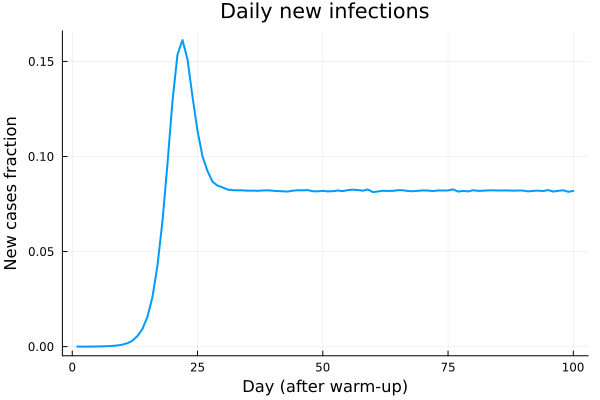

In [22]:
using DelimitedFiles
using Plots

# ---- Save mobility matrix ----
writedlm("mobility_matrix.csv", A, ',')

# ---- Save the daily incidence data ----
writedlm("daily_incidence.csv", long_inc, ',')

# ---- Plot new daily cases (fraction of population) ----
p1 = plot(long_inc,
          xlabel = "Day (after warm-up)", 
          ylabel = "New cases fraction",
          title  = "Daily new infections",
          legend = false,
          linewidth = 2)
savefig(p1, "daily_cases.png") 
p1  # or .pdf, .svg

In [31]:
using Random, Distributions, ProgressMeter, SparseArrays, JLD2

# ---------- Mobility matrix (unchanged) ----------
function make_mobility_matrix(num_zones::Int, density::Float64)
    return rand(Bernoulli(density), num_zones, num_zones)
end

# ---------- Initialisation (unchanged, returns a named tuple) ----------
function initial_state(N::Int, zone_size::Int, initial_infected::Int,
                       start_mode::Symbol; seed=nothing)
    !isnothing(seed) && Random.seed!(seed)
    num_zones_per_dim = N ÷ zone_size
    num_zones_total   = num_zones_per_dim^2
    total_nodes       = N * N
    home_x   = Vector{Int}(undef, total_nodes)
    home_y   = Vector{Int}(undef, total_nodes)
    zone_id  = Vector{Int}(undef, total_nodes)
    idx = 0
    for x in 1:N, y in 1:N
        idx += 1
        home_x[idx]  = x
        home_y[idx]  = y
        zx = (x-1) ÷ zone_size + 1
        zy = (y-1) ÷ zone_size + 1
        zone_id[idx] = (zx-1)*num_zones_per_dim + zy
    end
    infected = falses(total_nodes)
    if start_mode == :single_zone
        z = rand(1:num_zones_total)
        nodes_in_zone = findall(==(z), zone_id)
        n_infect = min(initial_infected, length(nodes_in_zone))
        infected[sample(nodes_in_zone, n_infect; replace=false)] .= true
    elseif start_mode == :random
        infected[sample(1:total_nodes, initial_infected; replace=false)] .= true
    else
        error("start_mode must be :single_zone or :random")
    end
    return (; home_x, home_y, zone_id, infected, N, zone_size,
              num_zones_per_dim, num_zones_total)
end

# ---------- Infection phase – now returns per‑zone new infections ----------
function apply_infection!(infected, cur_x, cur_y, beta, offsets, zone_id, periodic, N)
    total = length(infected)
    grid = [Vector{Int}() for _ in 1:N, _ in 1:N]
    for i in 1:total
        push!(grid[cur_x[i], cur_y[i]], i)
    end
    new_infected = falses(total)
    for i in findall(infected)
        cx, cy = cur_x[i], cur_y[i]
        for (dx, dy) in offsets
            nx = periodic ? mod1(cx + dx, N) : cx + dx
            ny = periodic ? mod1(cy + dy, N) : cy + dy
            if !periodic && (nx < 1 || nx > N || ny < 1 || ny > N)
                continue
            end
            for j in grid[nx, ny]
                if !infected[j] && !new_infected[j] && rand() < beta
                    new_infected[j] = true
                end
            end
        end
    end
    infected .|= new_infected
    # Count new infections per home zone
    zone_new = zeros(Int, maximum(zone_id))
    for i in findall(new_infected)
        zone_new[zone_id[i]] += 1
    end
    return zone_new
end

# ---------- One full day – returns OD matrix and zone new infections ----------
function step!(state, A, p_move, beta_day, beta_night, gamma; periodic)
    total_nodes = state.N^2
    num_zones = state.num_zones_total
    cur_x = copy(state.home_x)
    cur_y = copy(state.home_y)

    # ---- Movement and OD matrix ----
    OD = spzeros(Int, num_zones, num_zones)
    zones_nodes = [Int[] for _ in 1:num_zones]
    for i in 1:total_nodes
        push!(zones_nodes[state.zone_id[i]], i)
    end

    for z in 1:num_zones
        nodes = zones_nodes[z]
        n_move = round(Int, p_move * length(nodes))
        if n_move == 0 || isempty(nodes) continue end
        movers = sample(nodes, n_move; replace=false)
        dests = findall(>(0), A[z, :])   # indices of zones with link
        if isempty(dests) continue end
        for node in movers
            j = rand(dests)
            OD[z, j] += 1
            # place node randomly inside destination zone
            zx = (j-1) ÷ state.num_zones_per_dim + 1
            zy = (j-1) % state.num_zones_per_dim + 1
            cur_x[node] = (zx-1)*state.zone_size + rand(1:state.zone_size)
            cur_y[node] = (zy-1)*state.zone_size + rand(1:state.zone_size)
        end
    end

    # ---- Day infection ----
    offsets_day = [(dx, dy) for dx in -2:2 for dy in -2:2 if !(dx==0 && dy==0)]
    new_day = apply_infection!(state.infected, cur_x, cur_y, beta_day, offsets_day,
                               state.zone_id, periodic, state.N)

    # ---- Night: return home ----
    cur_x .= state.home_x
    cur_y .= state.home_y
    offsets_night = [(1,0), (-1,0), (0,1), (0,-1)]
    new_night = apply_infection!(state.infected, cur_x, cur_y, beta_night, offsets_night,
                                 state.zone_id, periodic, state.N)

    # Total new infections today per zone (day + night)
    zone_new = new_day .+ new_night

    # ---- Recovery (after night) ----
    for i in 1:total_nodes
        if state.infected[i] && rand() < gamma
            state.infected[i] = false
        end
    end
    return OD, zone_new
end

# ---------- Simulation that saves daily data ----------
function simulate_and_save(state, A, p_move, beta_day, beta_night, gamma;
                           days, warmup=0, periodic=true,
                           out_prefix = "sim")
    num_zones = state.num_zones_total
    new_inf = zeros(Int, num_zones, days + 1)   # column 1 = day 0 (zeros)
    zone_ever_infected = falses(num_zones)       # new
    od_dir = out_prefix * "_od"
    mkpath(od_dir)

    total_steps = warmup + days
    p = Progress(total_steps, dt=1.0, desc="Simulating: ")
    for d in 1:total_steps
        OD, zone_new = step!(state, A, p_move, beta_day, beta_night, gamma; periodic)
        if d > warmup
            day_idx = d - warmup
            new_inf[:, day_idx + 1] = zone_new
            # Mark zones that ever had an infection
            zone_ever_infected[zone_new .> 0] .= true
            jldsave(joinpath(od_dir, @sprintf("day_%03d.jld2", day_idx)); od = OD)
        end
        next!(p)
    end

    num_infected_zones = count(zone_ever_infected)
    jldsave(out_prefix * "_new_infections.jld2";
            new_inf = new_inf,
            num_communities = num_zones,
            zone_size = state.zone_size,
            N = state.N,
            beta_day = beta_day,
            beta_night = beta_night,
            p_move = p_move,
            gamma = gamma,
            mobility_matrix = A,
            num_infected_zones = num_infected_zones,
            zone_ever_infected = zone_ever_infected)   # optional, for deeper analysis
    println("Data saved with prefix: $out_prefix")
    return nothing
end

simulate_and_save (generic function with 1 method)

In [ ]:
# Settings (same as your original)
N = 1024
zone_size = 16          # 16×16 = 256 zones
p_move = 0.5
gamma = 0.1
β_opt = 0.03            # your found beta
periodic = false

# Mobility matrix (static, 5% ones)
num_zones = (N ÷ zone_size)^2
A = make_mobility_matrix(num_zones, 0.05)

# Initial state
seed = rand(UInt32)
state = initial_state(N, zone_size, 10, :single_zone; seed=seed)

# Output prefix including parameters
out_prefix = "zone$(zone_size)_N$(N)_beta$(β_opt)_pmove$(p_move)"

simulate_and_save(state, A, p_move, β_opt, β_opt, gamma;
                  days = 100, warmup = 10, periodic = periodic,
                  out_prefix = out_prefix)

Simulating:  70%|███████████████████████████▎           |  ETA: 0:05:35

Zones ever infected: 256
(Saved value: 256)


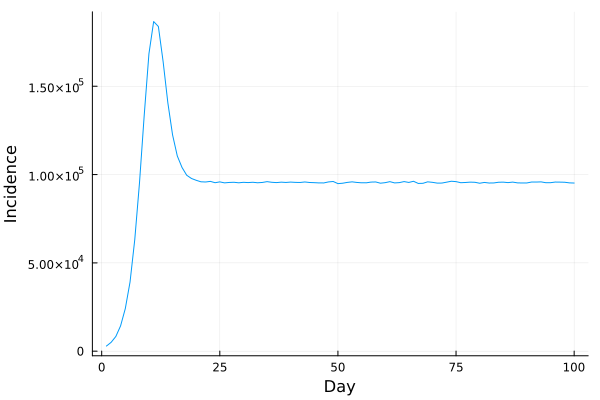

In [ ]:
using JLD2, Plots

out_prefix = "zone16_N1024_beta0.03_pmove0.5"
data = load(out_prefix * "_new_infections.jld2")
new_inf = data["new_inf"]

# Zone count
ever_infected = vec(any(new_inf .> 0, dims=2))
println("Zones ever infected: ", sum(ever_infected))
println("(Saved value: ", data["num_infected_zones"], ")")
# Incidence plot
daily_inc = vec(sum(new_inf, dims=1))[2:end]

plot(daily_inc, label="", xlabel="Day", ylabel="Incidence")



In [37]:
# =============================================================================
# Granger Causality on Lattice Community Data
# Supports Poisson and Linear (classical F) approaches.
# Randomizations: Real, DayShuffled, NodePermuted, SpatiotemporalShuffle
# Includes diagnostic correlation check for VE.
# =============================================================================

using JLD2, DataFrames, SparseArrays, CSV
using GLM, HypothesisTests, Statistics, Random, Distributions
using LinearAlgebra   # for diag
using Printf
# -----------------------------------------------------------------------------
# 1. Granger test functions (both Poisson and Linear)
# -----------------------------------------------------------------------------

# --- Poisson version (from original Poisson script) ---
function granger_f_test_poisson(y::Vector{Float64}, x::Vector{Float64}, lag::Int; add_trend::Bool=false)
    n = length(y)
    if n <= 2*lag + 1
        return NaN, NaN
    end
    df = DataFrame(y = y[lag+1:end])
    for l in 1:lag
        df[!, Symbol("ylag", l)] = y[(lag+1-l):(end-l)]
        df[!, Symbol("xlag", l)] = x[(lag+1-l):(end-l)]
    end
    if add_trend
        df.t = 1:size(df,1)
    end
    ylag_terms = sum([Term(Symbol("ylag", l)) for l in 1:lag])
    xlag_terms = sum([Term(Symbol("xlag", l)) for l in 1:lag])
    trend_term = add_trend ? Term(:t) : ConstantTerm(0)
    formula_r = Term(:y) ~ ylag_terms + trend_term
    formula_ur = Term(:y) ~ ylag_terms + xlag_terms + trend_term
    mod_r, mod_ur = try
        mod_r = glm(formula_r, df, Poisson(), LogLink())
        mod_ur = glm(formula_ur, df, Poisson(), LogLink())
        (mod_r, mod_ur)
    catch e
        @warn "Poisson GLM fitting failed: $e"
        return NaN, NaN
    end
    LRT = deviance(mod_r) - deviance(mod_ur)
    k = lag
    pval = LRT > 0 ? ccdf(Chisq(k), LRT) : 1.0
    return LRT, pval
end

function safe_adf_pvalue(x::Vector{Float64})
    try
        res = ADFTest(x, :constant, 5)
        p = pvalue(res)
        return isnan(p) ? 1.0 : p
    catch e
        @warn "ADF test failed: $e"
        return 1.0
    end
end

# --- Linear version (classical F-test) ---
function granger_f_test_linear(y::Vector{Float64}, x::Vector{Float64}, lag::Int)
    n = length(y)
    if n <= 2*lag + 1
        return NaN, NaN
    end
    df = DataFrame(y = y[lag+1:end])
    for l in 1:lag
        df[!, Symbol("ylag", l)] = y[(lag+1-l):(end-l)]
        df[!, Symbol("xlag", l)] = x[(lag+1-l):(end-l)]
    end
    formula_r = Term(:y) ~ sum([Term(Symbol("ylag", l)) for l in 1:lag])
    mod_r = lm(formula_r, df)
    formula_ur = Term(:y) ~ sum([Term(Symbol("ylag", l)) for l in 1:lag]) +
                           sum([Term(Symbol("xlag", l)) for l in 1:lag])
    mod_ur = lm(formula_ur, df)
    RSS_r = deviance(mod_r)
    RSS_ur = deviance(mod_ur)
    T = nrow(df)
    k = lag
    F = ((RSS_r - RSS_ur) / k) / (RSS_ur / (T - 2k - 1))
    pval = 1 - cdf(FDist(k, T - 2k - 1), F)
    return F, pval
end

# -----------------------------------------------------------------------------
# 2. Data loading (lattice community output)
# -----------------------------------------------------------------------------
function load_lattice_data(data_tag::String; data_dir::String = ".", n_sample::Union{Int, Nothing} = nothing)
    inf_file = joinpath(data_dir, data_tag * "_new_infections.jld2")
    # Use local variables inside the function (no global)
    local new_inf, num_comm, zone_size, num_infected_zones_full
    jldopen(inf_file, "r") do f
        new_inf = read(f, "new_inf")
        num_comm = read(f, "num_communities")
        zone_size = read(f, "zone_size")
        num_infected_zones_full = read(f, "num_infected_zones")
    end
    T = size(new_inf, 2) - 1
    Y_full = Float64.(new_inf[:, 2:end])

    od_dir = joinpath(data_dir, data_tag * "_od")
    M_full = Vector{SparseMatrixCSC{Int, Int}}(undef, T)
    for t in 1:T
        fname = joinpath(od_dir, @sprintf("day_%03d.jld2", t))
        jldopen(fname, "r") do f
            M_full[t] = read(f, "od")
        end
    end

    P_full = fill(Float64(zone_size * zone_size), num_comm)
    area_names_full = ["comm_$(i)" for i in 1:num_comm]

    if n_sample !== nothing && n_sample < num_comm
        Random.seed!(42)
        idx = sort(sample(1:num_comm, n_sample, replace=false))
        Y = Y_full[idx, :]
        P = P_full[idx]
        area_names = area_names_full[idx]
        M = [M_full[t][idx, idx] for t in 1:T]
        println("Using a random subset of $(n_sample) communities out of $(num_comm).")
        # Number of ever‑infected zones in the subset
        num_infected_zones = sum(maximum(Y, dims=2) .> 0)
    else
        Y = Y_full
        P = P_full
        area_names = area_names_full
        M = M_full
        num_infected_zones = num_infected_zones_full   # from the file
    end
    return Y, P, M, area_names, T, num_infected_zones
end
# 3. Mobility randomization (including spatiotemporal)
# -----------------------------------------------------------------------------

function randomize_mobility(M::Vector{SparseMatrixCSC{Int, Int}}; method::Symbol = :day_shuffle)
    T = length(M)
    n = size(M[1], 1)

    if method == :day_shuffle
        perm_days = randperm(T)
        return M[perm_days]

    elseif method == :node_permute
        perm = randperm(n)
        M_rand = similar(M)
        for t in 1:T
            Mt = M[t]
            I, J, V = findnz(Mt)
            I_perm = perm[I]
            J_perm = perm[J]
            M_rand[t] = sparse(I_perm, J_perm, V, n, n)
        end
        return M_rand

    elseif method == :spatiotemporal_shuffle
        # 1. Day shuffle
        perm_days = randperm(T)
        M_temp = M[perm_days]
        # 2. Within each day, randomly reassign all trips (i.e., permute all non‑zero entries)
        M_rand = similar(M_temp)
        for t in 1:T
            Mt = M_temp[t]
            I, J, V = findnz(Mt)
            nz = length(V)
            # Randomly assign new origins and destinations
            new_I = rand(1:n, nz)
            new_J = rand(1:n, nz)
            M_rand[t] = sparse(new_I, new_J, V, n, n)
        end
        return M_rand

    else
        error("Unknown method: $method")
    end
end

# -----------------------------------------------------------------------------
# 4. Viral Exposition
# -----------------------------------------------------------------------------

function compute_ve(Y, P, M)
    N, T = size(Y)
    VE_full = zeros(N, T)
    VE_diag = zeros(N, T)

    for t in 1:T
        Mt = M[t]
        y = Y[:, t]
        y_over_p = [P[i] > 0 ? y[i] / P[i] : 0.0 for i in 1:N]
        ve_full_t = Mt * y_over_p
        diag_m = diag(Mt)
        ve_diag_t = diag_m .* y_over_p
        ve_full_t .-= ve_diag_t
        VE_full[:, t] = ve_full_t
        VE_diag[:, t] = ve_diag_t
    end
    return VE_full, VE_diag
end

# -----------------------------------------------------------------------------
# 5. Granger runner (unified for Poisson/Linear)
# -----------------------------------------------------------------------------

function run_granger_fixed_lags(Y, VE_full, VE_diag, area_names;
                                lags = [1,2,3,4,5,6,7,8,9,10,11,12,13,14],
                                direction = :VE_to_Cases,
                                method = :linear)   # :poisson or :linear
    N, T = size(Y)
    results = DataFrame(
        Area = String[],
        Test_Type = String[],
        Lag = Int[],
        Stat = Float64[],      # F-stat for linear, LRT for Poisson
        P_Value = Float64[],
        Significant_α005 = Bool[],
        Stationarity_Action = String[],
        Notes = String[]
    )

    for i in 1:N
        cases_series = Y[i, :]
        ve_full_series = VE_full[i, :]
        ve_diag_series = VE_diag[i, :]
        area = area_names[i]

        if method == :poisson
            p_cases = safe_adf_pvalue(cases_series)
            p_ve_full = safe_adf_pvalue(ve_full_series)
            p_ve_diag = safe_adf_pvalue(ve_diag_series)
            need_trend_full = (p_cases > 0.05) || (p_ve_full > 0.05)
            need_trend_diag = (p_cases > 0.05) || (p_ve_diag > 0.05)
        end

        for test_type in ["Full VE", "Diagonal VE"]
            ve_series = (test_type == "Full VE") ? ve_full_series : ve_diag_series

            if method == :linear
                # For linear, we first difference if needed
                p_cases = safe_adf_pvalue(cases_series)
                p_ve = safe_adf_pvalue(ve_series)
                if p_cases > 0.05 || p_ve > 0.05
                    dep = diff(cases_series)
                    pred = diff(ve_series)
                    action = "First-differenced"
                else
                    dep = copy(cases_series)
                    pred = copy(ve_series)
                    action = "Original"
                end
                for lag in lags
                    F, p = granger_f_test_linear(dep, pred, lag)
                    sig = !isnan(p) && p < 0.05
                    push!(results, (area, test_type, lag, F, p, sig, action, ""))
                end
            else  # Poisson
                add_trend = (test_type == "Full VE") ? need_trend_full : need_trend_diag
                action = add_trend ? "Original + linear trend" : "Original (stationary)"
                for lag in lags
                    LRT, p = granger_f_test_poisson(cases_series, ve_series, lag; add_trend=add_trend)
                    sig = !isnan(p) && p < 0.05
                    push!(results, (area, test_type, lag, LRT, p, sig, action, ""))
                end
            end
        end
    end
    return results
end

# -----------------------------------------------------------------------------
# 6. Correlation diagnostic
# -----------------------------------------------------------------------------

function diagnostic_correlation(Y, VE_full, num_samples=3)
    println("\n--- Correlation diagnostic (first $num_samples communities) ---")
    for i in 1:min(num_samples, size(Y,1))
        println("Community $(i):")
        y = Y[i,:]
        ve = VE_full[i,:]
        println("  Cor(Y[t], VE[t])   = $(cor(y, ve))")
        for lag in 1:3
            if length(y) > lag
                println("  Cor(Y[t], VE[t-$lag]) = $(cor(y[1:end-lag], ve[lag+1:end]))")
            end
        end
    end
end

# -----------------------------------------------------------------------------
# 7. Main function
# -----------------------------------------------------------------------------

function main(; data_tag::String = "zone64_N1024_beta0.03_pmove0.5",
               n_sample::Union{Int, Nothing} = nothing,
               method::Symbol = :linear,
               data_dir::String = ".")
    println("Running Granger analysis (method = $method) for data tag: $data_tag")
    Y, P, M_real, area_names, T, num_infected_zones = load_lattice_data(
        data_tag; data_dir=data_dir, n_sample=n_sample
    )
    println("Data loaded: $(size(Y)) matrix, $(length(area_names)) communities, $T days.")
    println("Number of zones that were ever infected (after warmup): $num_infected_zones")

    scenarios = Dict(
        "Real"                => M_real,
        "DayShuffled"         => randomize_mobility(M_real; method=:day_shuffle),
        "NodePermuted"        => randomize_mobility(M_real; method=:node_permute),
        "SpatiotemporalShuffle" => randomize_mobility(M_real; method=:spatiotemporal_shuffle)
    )

    lags = [1,2,3,4,5,6,7,8,9,10,11,12,13,14]
    all_results = DataFrame()

    for (scenario, M) in scenarios
        println("Processing scenario: $scenario")
        VE_full, VE_diag = compute_ve(Y, P, M)
        if scenario == "Real"
            diagnostic_correlation(Y, VE_full, 3)
        end
        res = run_granger_fixed_lags(Y, VE_full, VE_diag, area_names;
                                     lags = lags, direction = :VE_to_Cases,
                                     method = method)
        res[!, :Mobility] .= scenario
        all_results = vcat(all_results, res, cols=:union)
    end

    all_results = all_results[:, [:Area, :Mobility, :Test_Type, :Lag,
                                  :Stat, :P_Value, :Significant_α005,
                                  :Stationarity_Action, :Notes]]

    outfile = "granger_$(method)_$(data_tag)_all_scenarios.csv"
    CSV.write(outfile, all_results)
    println("\nResults saved to $outfile")

    # After collecting results, print fractions
    println("\nFraction of ever-infected zones with significant Granger causality (p<0.05):")
    for scenario in keys(scenarios)
        sub = all_results[all_results.Mobility .== scenario .&&
                          all_results.Test_Type .== "Full VE" .&&
                          all_results.Significant_α005 .== true, :]
        sig_zones = length(unique(sub.Area))
        frac = sig_zones / num_infected_zones
        println("  $scenario : $sig_zones / $num_infected_zones = $(round(frac, digits=4))")
    end
    return all_results
end

main (generic function with 1 method)

In [38]:
# Inside the same directory, run:
main(data_tag = "zone64_N1024_beta0.03_pmove0.5", method = :linear)

Running Granger analysis (method = linear) for data tag: zone64_N1024_beta0.03_pmove0.5


┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55


Data loaded: (256, 100) matrix, 256 communities, 100 days.
Number of zones that were ever infected (after warmup): 256
Processing scenario: NodePermuted


┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)

Processing scenario: SpatiotemporalShuffle


...

┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55



--- Correlation diagnostic (first 3 communities) ---
Community 1:
  Cor(Y[t], VE[t])   = 0.9770673590628854
  Cor(Y[t], VE[t-1]) = 0.9003357848644454
  Cor(Y[t], VE[t-2]) = 0.7420409995651017
  Cor(Y[t], VE[t-3]) = 0.505604623113399
Community 2:
  Cor(Y[t], VE[t])   = 0.9834594984981713
  Cor(Y[t], VE[t-1]) = 0.9178800530654455
  Cor(Y[t], VE[t-2]) = 0.7630115605488105
  Cor(Y[t], VE[t-3]) = 0.5276913835406581
Community 3:
  Cor(Y[t], VE[t])   = 0.9791116329059553
  Cor(Y[t], VE[t-1]) = 0.9527098304009894
  Cor(Y[t], VE[t-2]) = 0.8289416666883346
  Cor(Y[t], VE[t-3]) = 0.6181171887162924


┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)
└ @ Main In[37]:55
┌ Warning: ADF test failed: SingularException(1)


Results saved to granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.csv

Fraction of ever-infected zones with significant Granger causality (p<0.05):
  NodePermuted : 256 / 256 = 1.0
  SpatiotemporalShuffle : 100 / 256 = 0.3906
  DayShuffled : 256 / 256 = 1.0
  Real : 256 / 256 = 1.0


Row,Area,Mobility,Test_Type,Lag,Stat,P_Value,Significant_α005,Stationarity_Action,Notes
,String,String,String,Int64,Float64,Float64,Bool,String,String
1,comm_1,NodePermuted,Full VE,1,104.557,0.0,true,Original,
2,comm_1,NodePermuted,Full VE,2,87.5553,0.0,true,Original,
3,comm_1,NodePermuted,Full VE,3,41.5557,1.11022e-16,true,Original,
4,comm_1,NodePermuted,Full VE,4,26.558,2.09832e-14,true,Original,
5,comm_1,NodePermuted,Full VE,5,20.2035,3.51164e-13,true,Original,
6,comm_1,NodePermuted,Full VE,6,16.2857,3.3078e-12,true,Original,
7,comm_1,NodePermuted,Full VE,7,13.1053,4.8873e-11,true,Original,
8,comm_1,NodePermuted,Full VE,8,9.88593,2.80759e-9,true,Original,
9,comm_1,NodePermuted,Full VE,9,7.18611,2.29903e-7,true,Original,


Summary saved to granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.txt


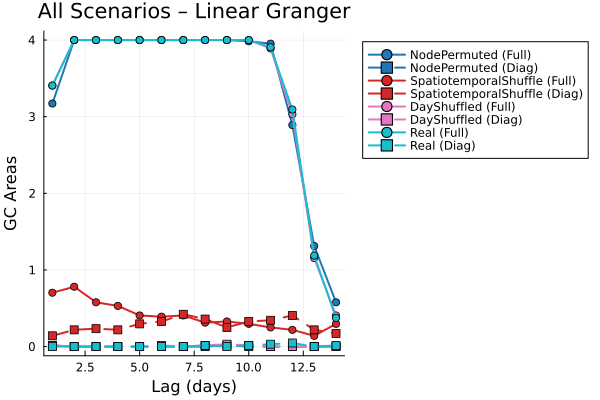

"/home/alec/Documents/lage_simple_lattice/granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.png"

In [39]:
using CSV, DataFrames

df = CSV.read("granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.csv", DataFrame)

scenarios = unique(df.Mobility)

open("granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.txt", "w") do io
    for sc in scenarios
        write(io, "=== Scenario: $sc ===\n")
        for lag in 1:14
            full = count(row -> row.Test_Type == "Full VE" && row.Lag == lag && row.Significant_α005,
                         eachrow(df[df.Mobility .== sc, :]))
            diag = count(row -> row.Test_Type == "Diagonal VE" && row.Lag == lag && row.Significant_α005,
                         eachrow(df[df.Mobility .== sc, :]))
            write(io, "  Lag $lag days -> Full VE: $full, Diagonal VE: $diag\n")
        end
        write(io, "\n")
    end
end

println("Summary saved to granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.txt")



using Plots

function parse_linear_data(filepath)
    # Returns: scenario => (lags, full_ve, diag_ve)
    data = Dict{String, Tuple{Vector{Int}, Vector{Int}, Vector{Int}}}()
    open(filepath, "r") do f
        current_scenario = nothing
        lags = Int[]
        full_ve = Int[]
        diag_ve = Int[]

        for line in eachline(f)
            line = strip(line)
            # Detect scenario header
            m = match(r"=== Scenario: (.+) ===", line)
            if m !== nothing
                # Save previous scenario if any
                if current_scenario !== nothing && !isempty(lags)
                    data[current_scenario] = (lags, full_ve, diag_ve)
                end
                current_scenario = m.captures[1]
                lags = Int[]
                full_ve = Int[]
                diag_ve = Int[]
                continue
            end

            # Parse data lines inside a scenario block
            if current_scenario !== nothing
                m = match(r"Lag (\d+) days -> Full VE: (\d+), Diagonal VE: (\d+)", line)
                if m !== nothing
                    push!(lags, parse(Int, m.captures[1]))
                    push!(full_ve, parse(Int, m.captures[2]))
                    push!(diag_ve, parse(Int, m.captures[3]))
                end
            end
        end
        # Save last scenario
        if current_scenario !== nothing && !isempty(lags)
            data[current_scenario] = (lags, full_ve, diag_ve)
        end
    end
    return data
end

function plot_all_original_scenarios(data; denominator=64)
    scenarios = collect(keys(data))
    p = plot(xlabel = "Lag (days)", ylabel = "GC Areas",
             title = "All Scenarios – Linear Granger",
             legend = :outertopright, grid = true, linestyle = :dot)

    colors = palette(:tab10, length(scenarios))
    for (i, scenario) in enumerate(scenarios)
        lags, full, diag = data[scenario]
        color = colors[i]
        # Solid line for Full VE
        plot!(p, lags, full/denominator, label = "$scenario (Full)",
              linewidth = 2, marker = :circle, color = color, linestyle = :solid)
        # Dashed line for Diagonal VE
        plot!(p, lags, diag/denominator, label = "$scenario (Diag)",
              linewidth = 2, marker = :rect, color = color, linestyle = :dash)
    end
    return p
end

# --- Main execution ---
filepath = "granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.txt"   # your summary file
data = parse_linear_data(filepath)
plt = plot_all_original_scenarios(data; denominator=8*8)   # 64 communities for k=64
display(plt)
savefig("granger_linear_zone64_N1024_beta0.03_pmove0.5_all_scenarios.png")
